[2026-08-02 12:11:31] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-06-30 23:59:59
[2026-08-02 12:11:45] [info     ] 因子 shape: (116903, 3)
        date instrument    factor
0 2024-01-02  000006.SZ  0.024018
1 2024-01-02  000012.SZ -0.005405
2 2024-01-02  000016.SZ  0.073563
3 2024-01-02  000019.SZ -0.015979
4 2024-01-02  000025.SZ -0.008166
5 2024-01-02  000028.SZ -0.018952
6 2024-01-02  000029.SZ  0.027027
7 2024-01-02  000030.SZ -0.005607
count    116903.000000
mean          0.000208
std           0.029281
min          -0.252747
25%          -0.013928
50%           0.001005
75%           0.016410
max           0.164545
Name: factor, dtype: float64
[2026-08-02 12:11:45] [info     ] 读取因子库...
[2026-08-02 12:11:46] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-02 12:11:47] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-02 12:11:48] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-02 12:11:49] [info     ] 对齐中证1000

时段,IC
2024-01-15~2024-02-08,0.0153

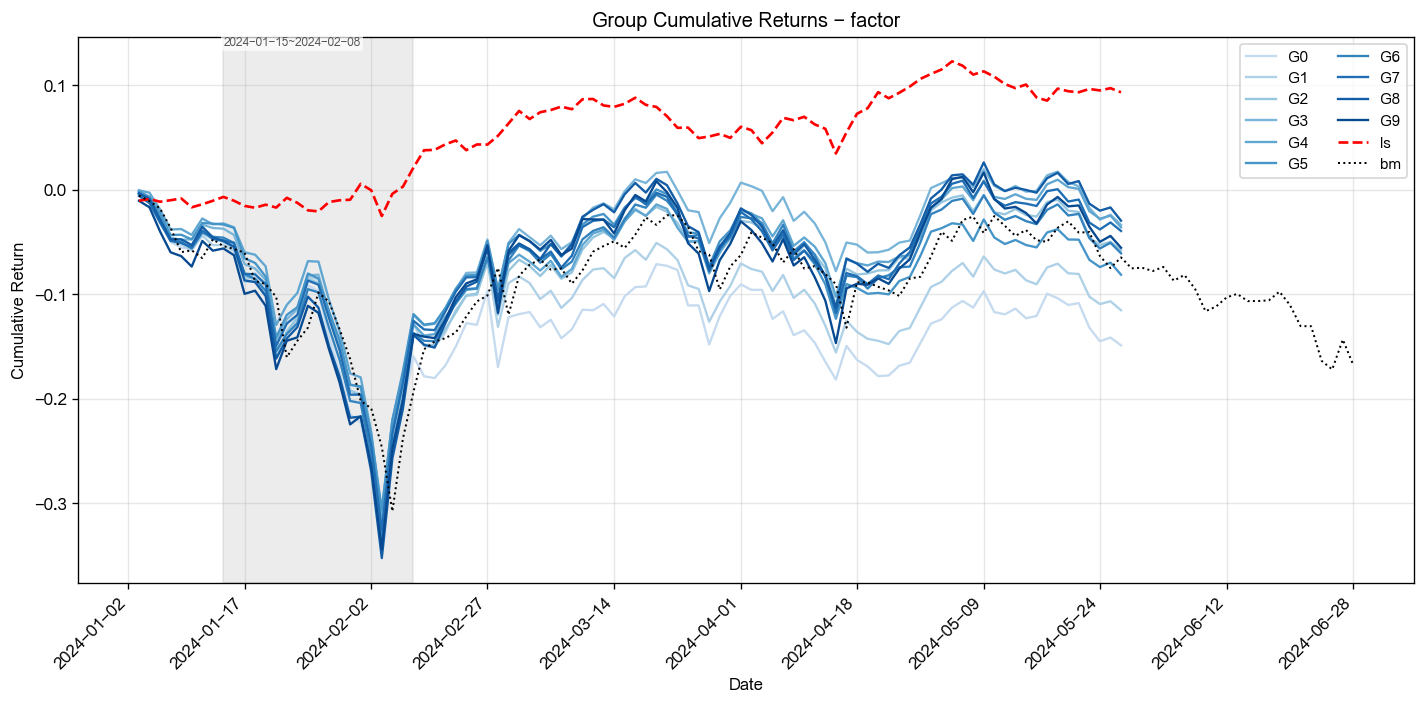
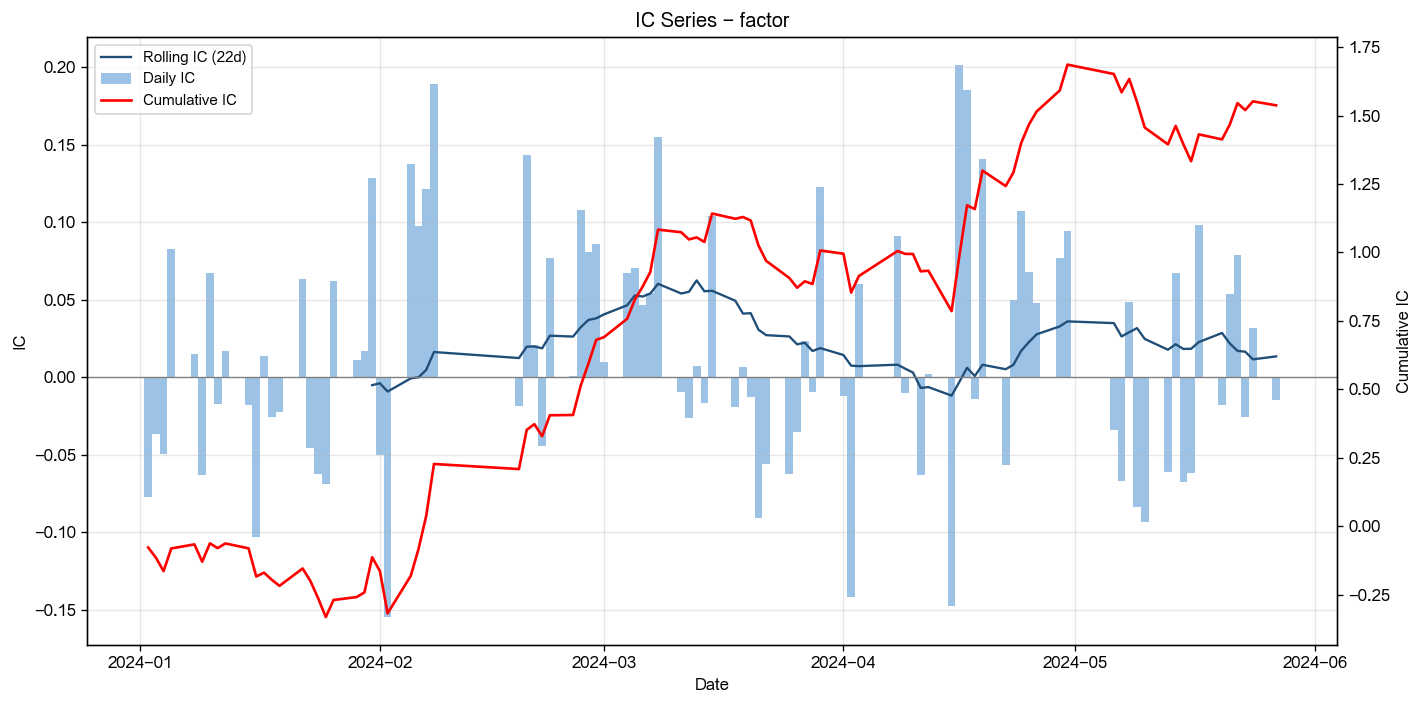
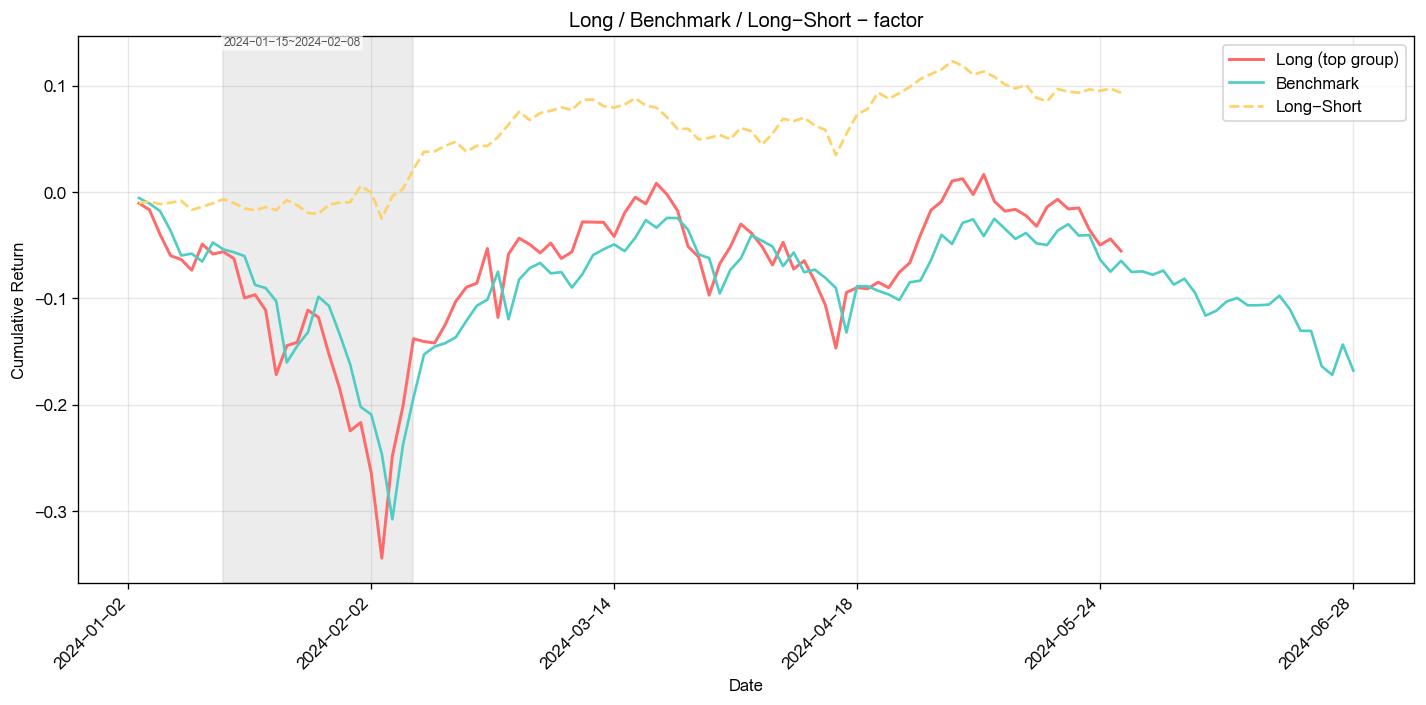
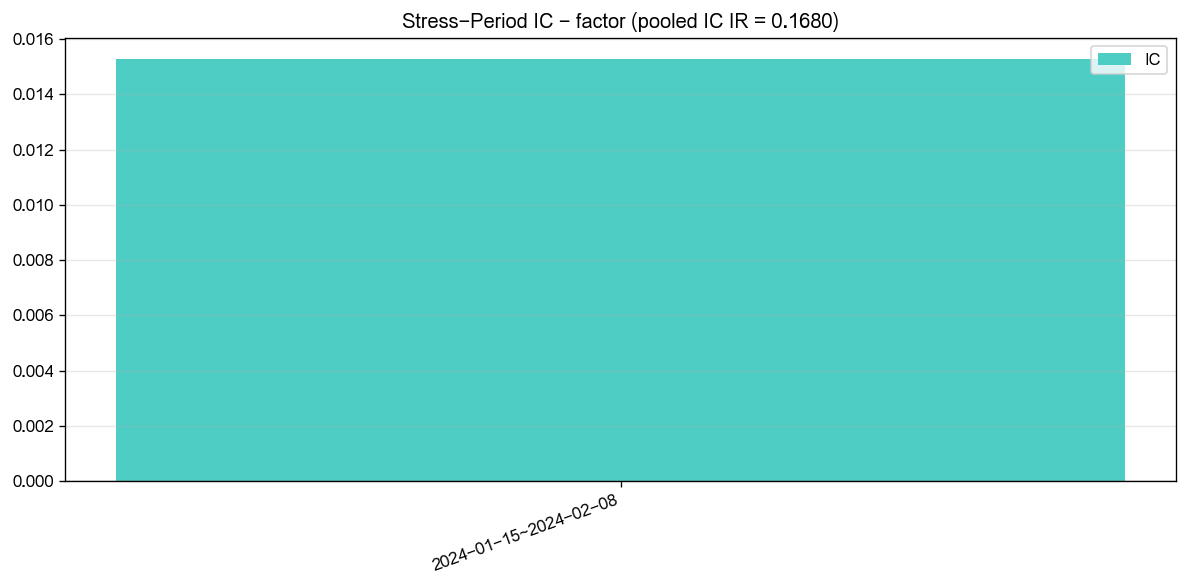
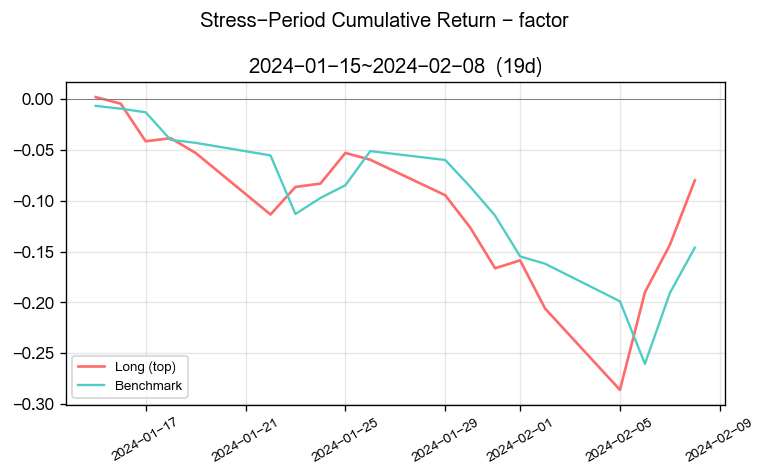

[2026-08-02 12:12:54] [info     ] ========== 因子池回归 ==========
[2026-08-02 12:12:55] [info     ] 加载 T+1 收益数据完成                  end_date=2024-06-28 instrument_count=1103 rows=138298 start_date=2024-01-02
[2026-08-02 12:12:55] [info     ] 获取收益率数据, 耗时: 1.5573 秒
[2026-08-02 12:12:56] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.9113 秒
[2026-08-02 12:12:56] [info     ] 统计 回归结果, 耗时: 0.0144 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,4.8808,0.0400,0.0082,1.0000
2,gross_profit_rate_ttm,4.7740,0.0109,0.0023,1.0000
3,kdj_d_9_3_3,3.6423,0.0166,0.0046,1.0000
4,net_profit_rate_ttm,3.0680,0.0060,0.0020,1.0000
5,macd_dea_12_26_9,2.9707,0.0090,0.0030,1.0000
6,daily_return,2.8965,0.0348,0.0120,1.0000
7,turn,2.2700,0.0113,0.0050,1.0000
8,roa_avg_ttm,2.2186,0.0211,0.0095,1.0000
9,net_active_buy_amount_main,2.2065,0.0211,0.0096,1.0000
10,netflow_amount_main,2.1696,0.0363,0.0167,1.0000

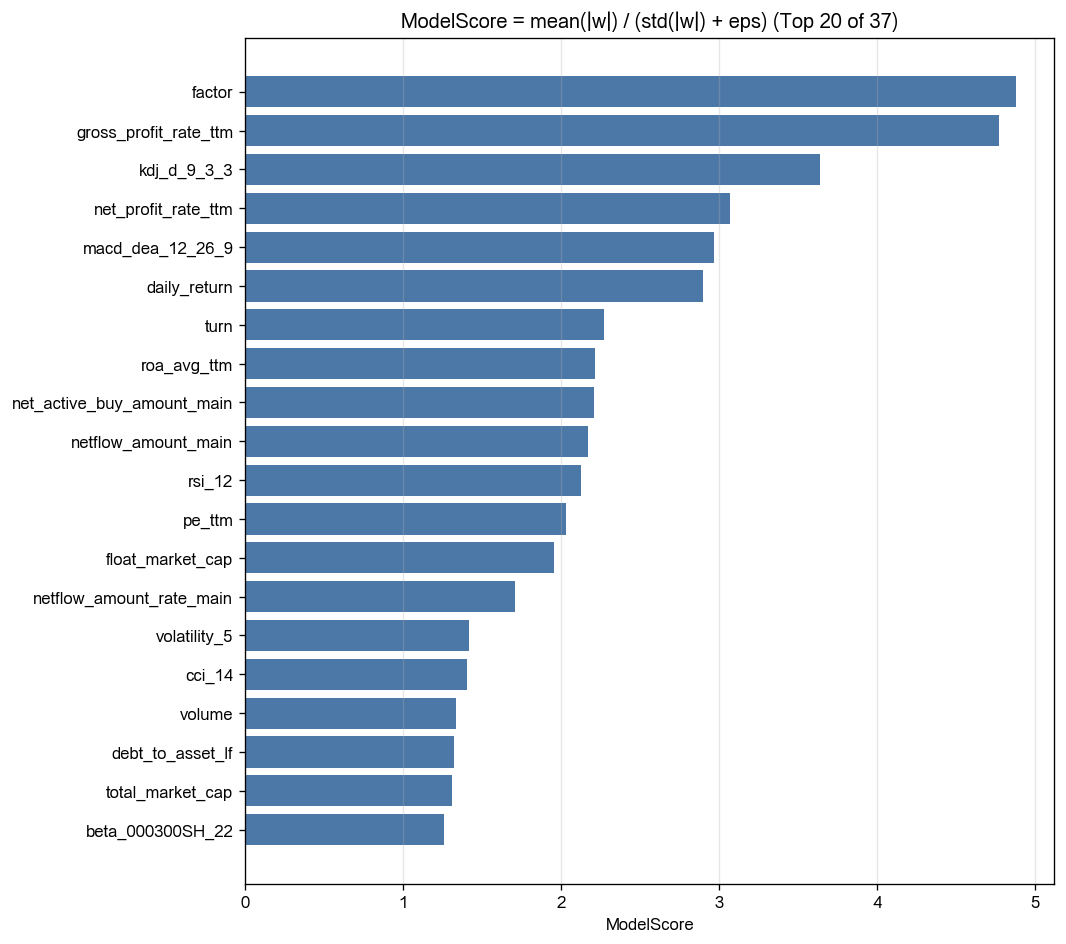
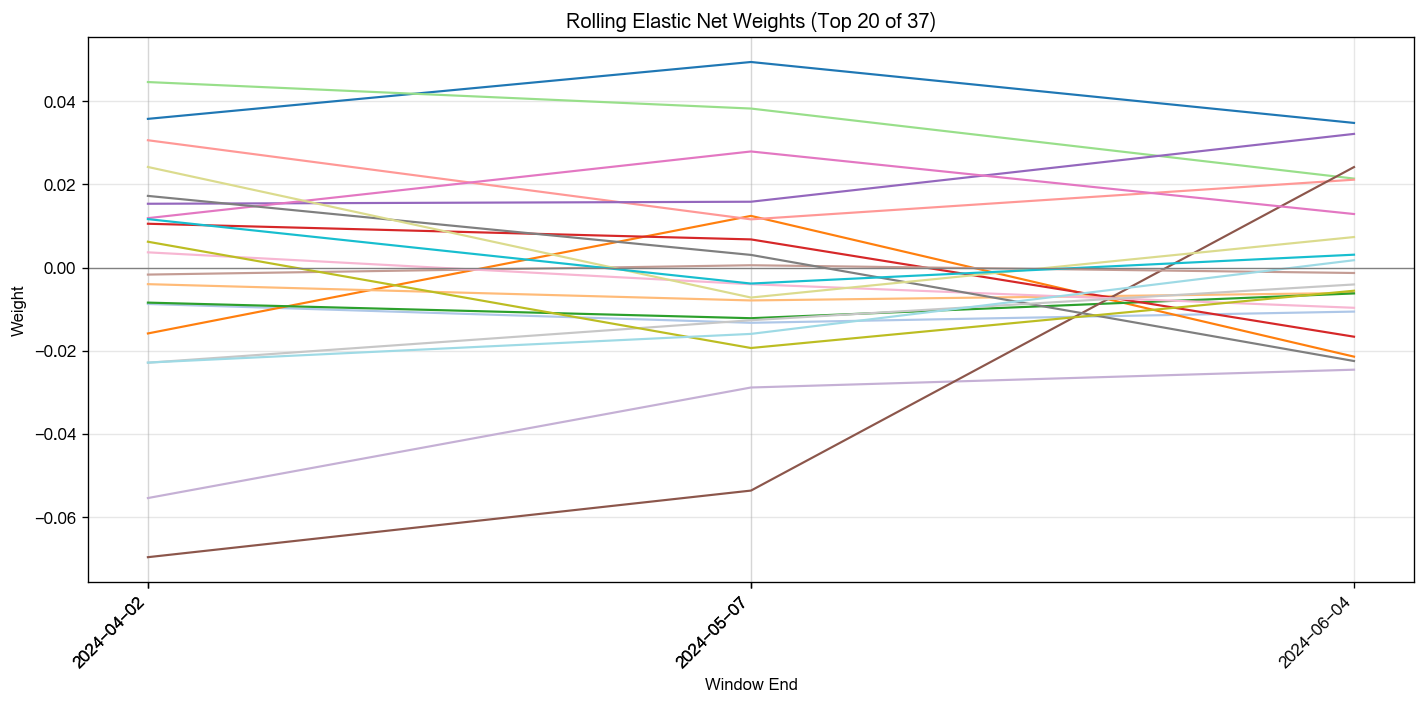
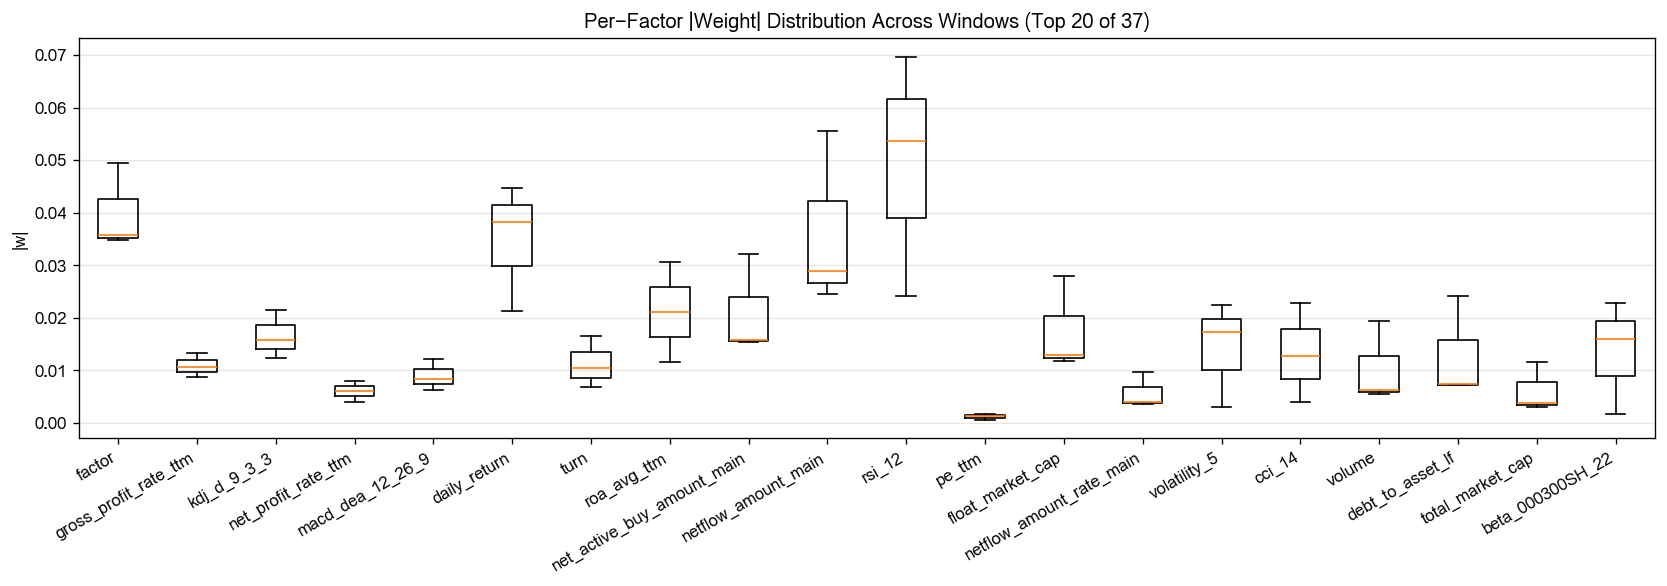
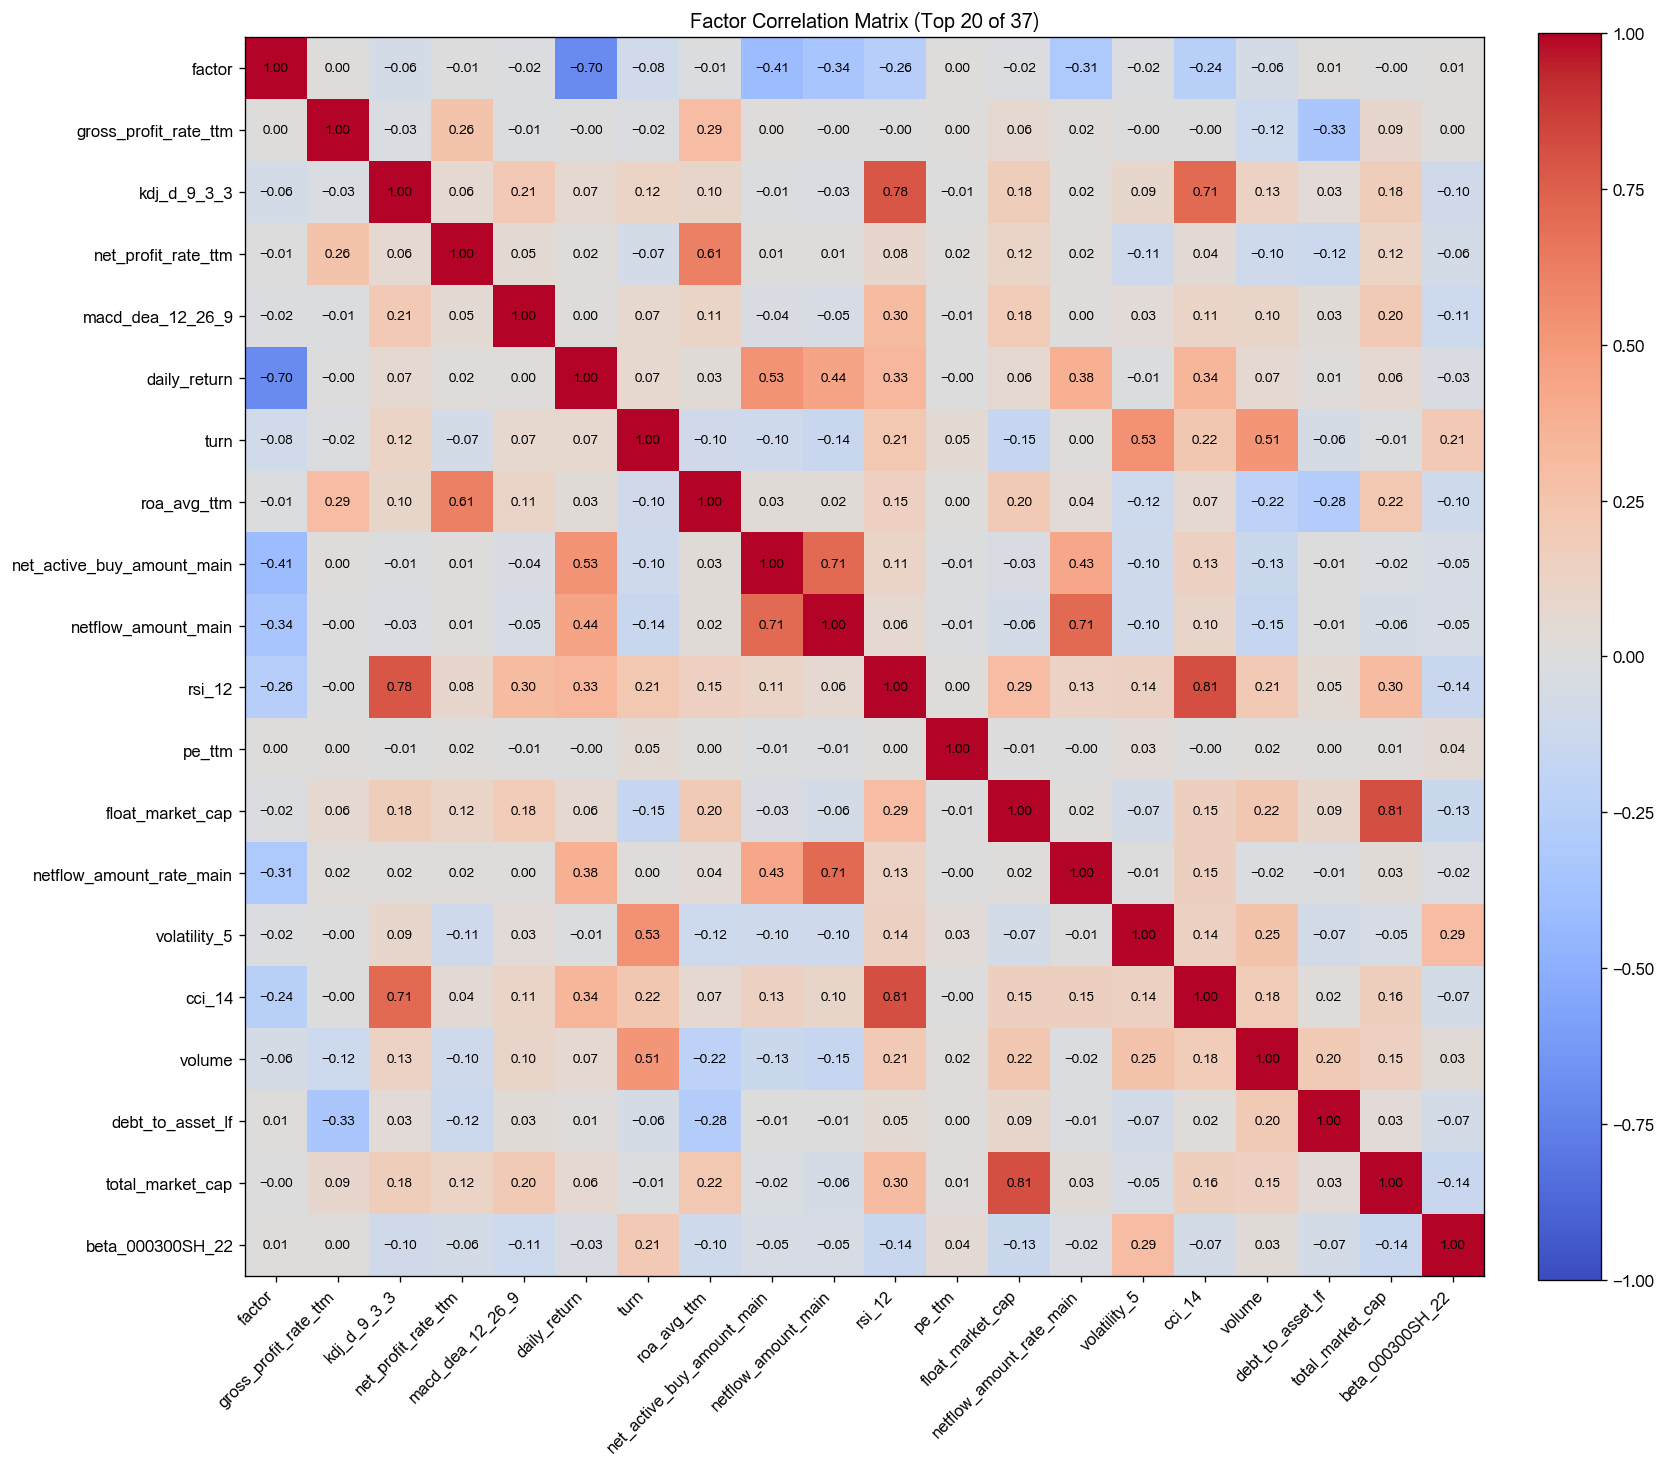

[2026-08-02 12:13:00] [warning  ] 返回的Outputs实例(size=16357534) 大于 64K, 将不会被缓存
[2026-08-02 12:13:00] [info     ] bigalpha_eval.v4 运行完成 [72.222s].


In [5]:
def main(datasources, start_date, end_date):
    """
    New Factor: Daily Intraday Return (Close / Open - 1)
    
    Simple and clean.
    We start with mean-reversion direction (-1 * intraday return).
    """
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    LOOKBACK_DAYS = 1
    query_start_date = (pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)).strftime("%Y-%m-%d %H:%M:%S")

    sql = f"""
    WITH daily AS (
        SELECT
            strftime(date, '%Y-%m-%d') AS trading_day,
            instrument,
            FIRST(open ORDER BY date) AS day_open,          -- first open of the day
            LAST(close ORDER BY date) AS day_close,         -- last close of the day
            SUM(volume) AS day_volume,
            COUNT(*) AS n_minutes
        FROM {bar1m}
        WHERE open > 0 AND close > 0 AND volume > 0
        GROUP BY trading_day, instrument
        HAVING n_minutes >= 60 AND day_volume > 0
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        -- Mean-reversion direction first
        -1.0 * (day_close / day_open - 1) AS factor
    FROM daily
    ORDER BY trading_day, instrument
    """

    df = dai.query(
        sql,
        filters={"date": [query_start_date, end_date]},
        compression=True
    ).df()

    # Align with CSI 1000
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()

    df = pd.merge(df, stk_pool, how="inner", on=["date", "instrument"])
    df = df.replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["factor"])

    return df[["date", "instrument", "factor"]]


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}

    start_date = "2024-01-01 00:00:00"
    end_date   = "2024-06-30 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)
    logger.info(f"因子 shape: {factor_data.shape}")
    print(factor_data.head(8))
    print(factor_data["factor"].describe())

    logger.info("读取因子库...")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )